# Descripción :
Este notebook se utilizo como ayuda visual para la implementacion de los pipelines que permiten tener buenas practicas y escalabilidad en el desarrollo. Adicionalmente se deja un apartado que permita calificar a los nuevos clientes para asi obtner un seguimiento de alertas para esto se debe tener claro la aplicacion y peridicidad, si bien este es un tema muy importante en una empresa finaciera se esperaria que la configuracion fuera lo mas cercano a tiempo real o un plazo no superior a 24 horas .

Dentro de la estructura de kedro comparto las rutas donde puden ir a ver con mas detalles las etapas de este desarrollo:
* Pipeline de preprocesamiento: src/analisis_fraude/pipelines/preprocessing
* Pipeline de modelo :src/analisis_fraude/pipelines/models

El artefacto para calificar la base lo podran encontrar en el repositorio en la siguiente ruta:
data\06_models\isolation_forest_model_v4.pkl


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys 
# import scikitplot as skplt
import scipy.stats as stats
import pickle
from sklearn.ensemble import IsolationForest
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
os.chdir("C:/Users/sergi/Documents/Pruebas Técnicas/Nequi DS/Analisis_fraude/analisis-fraude/")


In [3]:
import src.analisis_fraude.pipelines.preprocessing.nodes as processing
import src.analisis_fraude.pipelines.models.nodes as models

## Lectura

In [8]:
%%time
file_path = "data/01_raw/sample_data_0006_part_00.parquet" # todos los datos
data = pd.read_parquet(file_path)

CPU times: total: 24.6 s
Wall time: 40.6 s


In [9]:
data= data.sample(n=10000, random_state=42)

## Preprocesing

Este archivo contiene las siguientes funciones:

clean_data: Limpia los datos, eliminando valores nulos y transformando formatos.
feature_engineering: Crea variables derivadas como:
Indicador de fin de semana.
Ventanas temporales de 24 horas.
Suma, promedio y frecuencia de transacciones.
scaling: Escala las variables numéricas usando StandardScaler.

In [10]:
# Aplicar las funciones
print("\nLimpieza de datos...")
cleaned_data = processing.clean_data(data)
cleaned_data.head(5)


Limpieza de datos...


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type
1081054,075d178871d8d48502bf1f54887e52fe,b69a8ad1a8280b8e6f0bd38b4cce8a4a,a8bd47b85e2b946052d816b208b3f0a4,2021-06-28 16:26:07,cb8cc7fef9d4410878603dad13f54cf5,ba11d753ac9444bc5f03fbd9fd98d923,594.44550123,DEBITO
2471502,817d18cd3c31e40e9bff0566baae7758,650dcc8f0c905205f35b65d7ac5998b2,540c5783008d512771471e186f77d9be,2021-10-14 18:12:15,344adb90dd50281461e4429b69ce6eb3,4968649a6a6db0989e193923c1436c09,118.88910024,DEBITO
6868479,817d18cd3c31e40e9bff0566baae7758,87be795748f41e4a4a97d783ce1f14cf,e3a9434b7e145d952d296cb255055b0f,2021-04-06 15:21:37,22cd1818eb77a5f0e25aacbfde8b24bf,15325b33069a73ac4ee0f6bf5e30d6fb,356.66730074,DEBITO
9424293,838a8fa992a4aa2fb5a0cf8b15b63755,d99542642ab30f13a7676c46b423ea22,207693b4bb0a84615b2a4f002a483b0a,2021-08-16 14:59:33,ea9122c8693053dea289a414caab5521,96e95977ba74cd6a2d0cf76bb6a9b3b5,271.86727220,CREDITO
6613222,817d18cd3c31e40e9bff0566baae7758,be7fd6155c65aeb95df167bf07dffd90,855e9baef9ba84ed74598c5a7de076d7,2021-09-17 20:39:45,22a07e37f9b02910126f702115884931,8b933efcc209a3269003ec7975b8a9a5,59.44455012,DEBITO


In [11]:
print("\nGeneración de variables derivadas...")
features = processing.feature_engineering(cleaned_data)
features.head(5)


Generación de variables derivadas...


C:\Users\sergi\Documents\Pruebas Técnicas\Nequi DS\Analisis_fraude\analisis-fraude\src\analisis_fraude\pipelines\preprocessing\nodes.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  clean_data.loc[:, 'window_24h'] = clean_data['transaction_date'].dt.floor('24H')


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,year,month,day,time_diff,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,std_amount
0,838a8fa992a4aa2fb5a0cf8b15b63755,8ae339d486d241b083da92151bbad9f9,f54e0b6b32831a6307361ed959903e76,2021-02-05 12:24:34,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.565366,DEBITO,2021,2,5,0.138179,4,0,2021-02-05,5.94445501,1,5.944455,NaN
1,838a8fa992a4aa2fb5a0cf8b15b63755,e07bd7b606a1be24d55d37c2aa71cacb,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-13 15:43:51,5f885e75bc34296f7c261ec5b1289beb,8f79b890b160711088967398e35b9252,-0.461518,DEBITO,2021,2,13,0.014311,5,1,2021-02-13,22.11337264,1,22.113373,NaN
2,838a8fa992a4aa2fb5a0cf8b15b63755,c43f66fcd4172bca435b5e8af14ba514,d4b621a24cc03e3f92155a7e241fa1c3,2021-01-05 12:58:46,5e9d5252baa6801de277305aa2fcfeaa,ccd856b4075077657f336d1aa626f56b,-0.565366,CREDITO,2021,1,5,-0.140934,1,0,2021-01-05,5.94445501,1,5.944455,NaN
3,838a8fa992a4aa2fb5a0cf8b15b63755,9059f5341cb5f28893a9a739d6c5eb31,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-16 14:01:24,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.565366,DEBITO,2021,2,16,0.126612,1,0,2021-02-16,5.94445501,1,5.944455,NaN
4,838a8fa992a4aa2fb5a0cf8b15b63755,5dd1991276d30cc92c12317c8e997fd8,f54e0b6b32831a6307361ed959903e76,2021-01-11 10:48:00,34355700491baab07bc889821ce82c88,ea36979228a4393d63884e01023f1514,-0.565343,CREDITO,2021,1,11,-0.400214,0,0,2021-01-11,5.94802168,1,5.948022,NaN


In [12]:
print("\nEscalado de variables...")
normalize_features = processing.normalize_features(features)
normalize_features.head()



Escalado de variables...


C:\Users\sergi\Documents\Pruebas Técnicas\Nequi DS\Analisis_fraude\analisis-fraude\src\analisis_fraude\pipelines\preprocessing\nodes.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_data[features] = feature_data[features].apply(pd.to_numeric, errors='coerce')


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,year,month,day,time_diff,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,std_amount
3,838a8fa992a4aa2fb5a0cf8b15b63755,9059f5341cb5f28893a9a739d6c5eb31,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-16 14:01:24,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.452909,DEBITO,2021,2,16,1.162812,1,0,2021-02-16,5.94445501,1,5.944455,NaN
44,838a8fa992a4aa2fb5a0cf8b15b63755,0f146cbf3c09c570e41f37bcf19feba7,f54e0b6b32831a6307361ed959903e76,2021-01-23 20:05:27,2a77707d2f542ec2ab9700a8389ee114,f5827c28fa4a5bd9b9e3a82366b12e44,1.788771,CREDITO,2021,1,23,1.014705,5,1,2021-01-23,17.83336503,1,17.833365,NaN
81,838a8fa992a4aa2fb5a0cf8b15b63755,07347c338582bf73f4d18aadc6c04c95,f54e0b6b32831a6307361ed959903e76,2021-02-14 10:39:51,f796e28e2884eeed40fb7ab3457ff889,11044f60596286a6bb3d25bef7909a10,-0.430492,DEBITO,2021,2,14,-0.619186,6,1,2021-02-14,12.00779912,2,6.0039,0.084067
115,838a8fa992a4aa2fb5a0cf8b15b63755,15a6d67379407b8a64f1dc8b072161c8,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-12 18:12:29,f796e28e2884eeed40fb7ab3457ff889,11044f60596286a6bb3d25bef7909a10,-0.452909,DEBITO,2021,2,12,-0.880785,4,0,2021-02-12,5.94445501,1,5.944455,NaN
124,838a8fa992a4aa2fb5a0cf8b15b63755,7e3969600260dba7482ce68440491a76,dff70ce33784a932ce4a7efc81a43863,2021-01-12 07:59:47,cd6d04f6ffa5f16a55dc9a26e588bfc1,7a4740d97e9f869ed3c044a3607aff4b,-0.452461,DEBITO,2021,1,12,-0.677546,1,0,2021-01-12,11.89247669,2,5.946238,0.000841


# Models 

In [14]:
# Lista de características seleccionadas
features = ['transaction_amount', 'time_diff']

# Parámetros para Isolation Forest
model_params = {
    'n_estimators': 150,
    'contamination': 0.08,
    'random_state': 42
}


In [15]:
data_with_anomalies, isolation_forest_model= models.train_isolation_forest(normalize_features, features, model_params)

In [17]:
# Definir las rutas de salida
result_path = 'data/07_model_output/anomaly_detection_results.csv'
model_path = 'data/06_models/isolation_forest_model_v2.pkl'

# Llamar a la función para guardar resultados
models.save_results(data_with_anomalies, isolation_forest_model, result_path, model_path)

Results saved to data/07_model_output/anomaly_detection_results.csv
Model saved to data/06_models/isolation_forest_model_v2.pkl


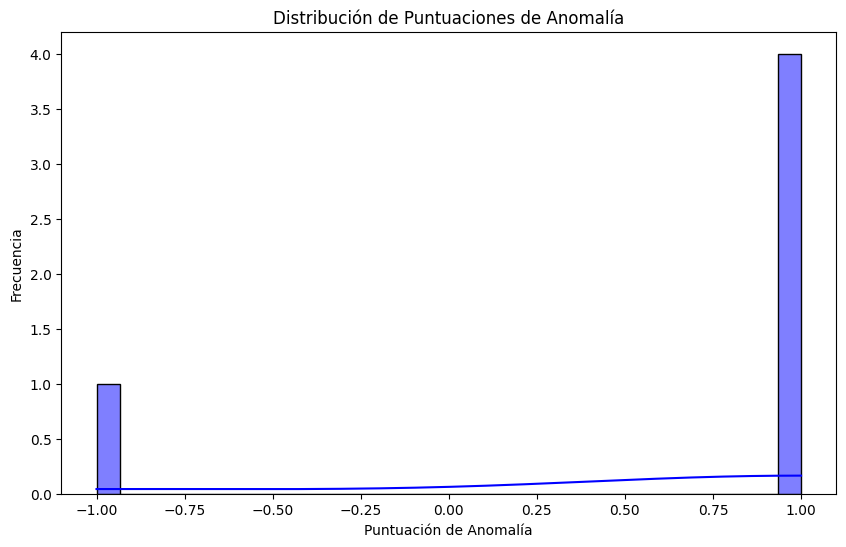

In [18]:
# Trazar un histograma
plt.figure(figsize=(10, 6))
sns.histplot(data_with_anomalies['anomaly_score'], kde=True, bins=30, color='blue')
plt.title('Distribución de Puntuaciones de Anomalía')
plt.xlabel('Puntuación de Anomalía')
plt.ylabel('Frecuencia')
plt.show()

In [40]:
# Ajustar el umbral a partir del percentil 90
percentil_90 = data_with_anomalies['anomaly_score'].quantile(0.95)

print(f"Umbral para el percentil 90: {percentil_90}")

# Identificar anomalías con nuevo umbral
data_with_anomalies['is_anomalous'] = data_with_anomalies['anomaly_score'] > percentil_90


Umbral para el percentil 90: 1.0


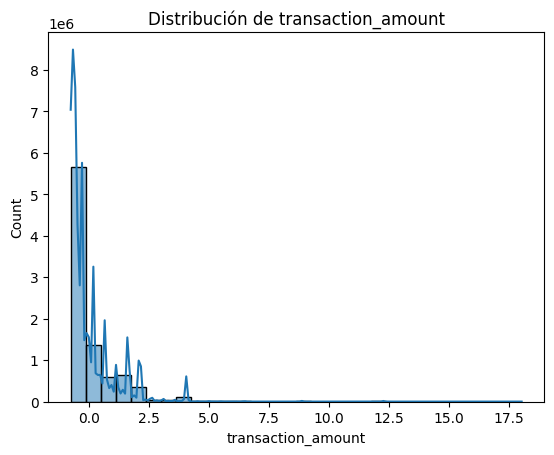

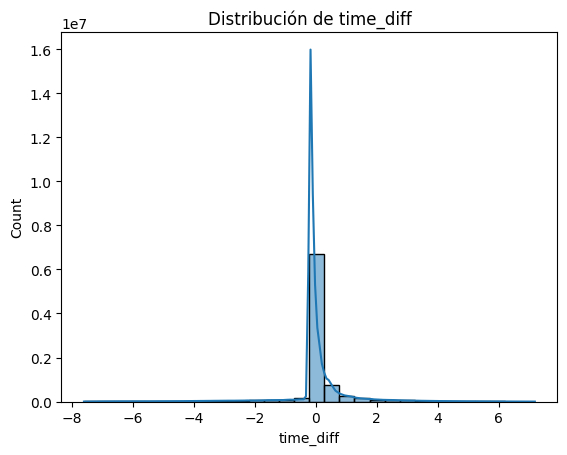

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la distribución de transaction_amount
sns.histplot(data['transaction_amount'], kde=True, bins=30)
plt.title('Distribución de transaction_amount')
plt.show()

# Visualizar la distribución de time_diff
sns.histplot(data['time_diff'], kde=True, bins=30)
plt.title('Distribución de time_diff')
plt.show()


In [46]:
# Promedio histórico por usuario
data['mean_amount_user'] = data.groupby('user_id')['transaction_amount'].transform('mean')

# Desviación estándar por usuario
data['std_amount_user'] = data.groupby('user_id')['transaction_amount'].transform('std')

# Relación entre transacción actual y promedio histórico
data['amount_ratio'] = data['transaction_amount'] / data['mean_amount_user']

# Número de transacciones en una ventana de 24 horas
data['transaction_count_24h'] = data.groupby(['user_id', 'window_24h'])['transaction_amount'].transform('count')


# Calificar Nueva base 

In [ ]:
# Cargar el modelo desde la ruta
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

# Verificar el tipo de objeto cargado
print(type(loaded_model))  # Esto debería mostrar <class 'sklearn.ensemble._iforest.IsolationForest'>



In [ ]:
df=catalog.load('normalized_features')

In [ ]:
# Usar el modelo para hacer predicciones
predictions = loaded_model.predict(df[features])
